In [12]:
import datetime
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import random

import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
# from keras.models import Sequential
# from keras.layers import Dense, LSTM, Input, Flatten, GRU
# from keras import backend

from scipy.fft import fft, ifft, fftfreq
import pywt
import warnings
import os
import gc

## Fourier Denoising functions:

In [13]:
## Padding-based Fourier Transform, based on Song et al. (2021):
def padding_fourier(stock_data, quantile_percent, nr_padding_samples):
  denoised_stock_data = pd.DataFrame()

  for i in range(len(stock_data.columns)):
    xt = stock_data[stock_data.columns[i]].reset_index(drop=True)

    ## Creating the padding:
    X1_bar = np.sqrt(np.mean(xt[:20]))
    X2_bar = np.sqrt(np.mean(xt[-20:]))

    sigma1 = np.sqrt(np.mean(xt[:20]-X1_bar))
    sigma2 = np.sqrt(np.mean(xt[-20:]-X2_bar))

    np.random.seed(i)
    N1_list = np.random.normal(loc=0, scale=sigma1, size=nr_padding_samples)
    N2_list = np.random.normal(loc=0, scale=sigma2, size=nr_padding_samples)

    lower_pad_series = pd.Series(np.flip(N1_list.cumsum())+xt.iloc[0])
    upper_pad_series = pd.Series(N1_list.cumsum()+xt.iloc[-1])

    xt = pd.concat([lower_pad_series, xt, upper_pad_series], ignore_index=True)

    fxt = np.fft.fftn(xt)
    if stock_data.columns[i] == 'Volume':
      threshold_value = np.quantile(np.abs(fxt), [0.99])
    else:
      threshold_value = np.quantile(np.abs(fxt), [quantile_percent])
    index = abs(fxt)> threshold_value[0] #list[i]
    fxt_clean = fxt*index.T
    xt_clean = np.fft.ifftn(fxt_clean)

    xt_unpadded = xt_clean[nr_padding_samples:-nr_padding_samples]
    denoised_stock_data[stock_data.columns[i]] = xt_unpadded.real

  denoised_stock_data.index = stock_data.index
  return denoised_stock_data

In [14]:
def fourier_window_renoising(stock_data, quantile_percent, window_coeff):
  denoised_stock_data = pd.DataFrame()

  for i in range(len(stock_data.columns)):
    xt = stock_data[stock_data.columns[i]]
    fxt = np.fft.fftn(xt)
    if stock_data.columns[i] == 'Volume':
      threshold_value = np.quantile(np.abs(fxt), [0.99])
    else:
      threshold_value = np.quantile(np.abs(fxt), [quantile_percent])
    index = abs(fxt)> threshold_value[0]
    fxt_clean = fxt*index.T
    xt_clean = np.fft.ifftn(fxt_clean)

    index_renoise = abs(fxt)<= threshold_value[0]
    fxt_renoise = fxt*index_renoise.T
    xt_renoise = np.fft.ifftn(fxt_renoise)
    if stock_data.columns[i] == 'Volume':
      a = 20/len(xt_renoise)**2
    else:
      a = window_coeff/len(xt_renoise)**2
    date_range = np.linspace(0,len(stock_data)-1,len(stock_data))
    renoise_window = np.maximum(0,a*date_range*(date_range-len(xt_renoise))+1)
    fwr_data = xt_clean+xt_renoise*renoise_window
    denoised_stock_data[stock_data.columns[i]] = fwr_data.real

  denoised_stock_data.index = stock_data.index
  return denoised_stock_data



In [15]:
def linear_drift_denoising(stock_data, quantile_percent):
  denoised_stock_data = pd.DataFrame()

  date_range = np.linspace(0,len(stock_data)-1,len(stock_data))
  for i in range(len(stock_data.columns)):
    xt = stock_data[stock_data.columns[i]]
    lin_drift_slope = (xt.iloc[-1] - xt.iloc[0])/len(xt)
    lin_drift = []
    for j in date_range:
      lin_drift.append(float(xt.iloc[0] + lin_drift_slope * j))
    xt_undrifted = xt - lin_drift
    fxt = np.fft.fft(xt_undrifted)
    if stock_data.columns[i] == 'Volume':
      threshold_value = np.quantile(np.abs(fxt), [0.99])
    else:
      threshold_value = np.quantile(np.abs(fxt), [quantile_percent])
    index = abs(fxt)> threshold_value[0]
    fxt_clean = fxt*index
    xt_clean = np.fft.ifft(fxt_clean)
    xt_clean = xt_clean.real
    xt_clean_redrifted = xt_clean + lin_drift

    denoised_stock_data[stock_data.columns[i]] = xt_clean_redrifted

  denoised_stock_data.index = stock_data.index
  return denoised_stock_data

In [16]:
def stationary_denoising(stock_data, quantile_percent, min_max_range, smoothing_range):
  ## -------------- Creating the variable Min-Max range: ----------------------
  min_val = stock_data.head(min_max_range).min().tolist()
  max_val = stock_data.head(min_max_range).max().tolist()

  min_list_vals = [min_val[:] for _ in range(min_max_range)]
  max_list_vals = [max_val[:] for _ in range(min_max_range)]

  # test_len

  for i in range(len(stock_data)-min_max_range):
    min_val = stock_data.iloc[i:i+min_max_range,:].min().tolist()
    max_val = stock_data.iloc[i:i+min_max_range,:].max().tolist()
    min_list_vals.append(min_val)
    max_list_vals.append(max_val)

  # min_list = pd.DataFrame()
  # max_list = pd.DataFrame()

  min_list = pd.DataFrame(min_list_vals, columns = stock_data.columns.tolist())
  max_list = pd.DataFrame(max_list_vals, columns = stock_data.columns.tolist())

  min_list.index = stock_data.index
  max_list.index = stock_data.index

  ## Setting fixed scaling range for Volume to improve consistency:
  min_list['Volume'] = stock_data['Volume'].min()
  max_list['Volume'] = stock_data['Volume'].max()

  avg_list = (min_list+max_list)/2

  data_scaled = (stock_data - avg_list)/(max_list - min_list)

  ## -------- Smoothing the minmax scaling: --------------
  min_list_smoothed = min_list.iloc[:smoothing_range,:].values.tolist()
  max_list_smoothed = max_list.iloc[:smoothing_range,:].values.tolist()

  for i in range(len(min_list)-int(2*smoothing_range)):
    min_vals_smoothed = min_list.iloc[i:i+int(2*smoothing_range),:].mean().values.tolist()
    min_list_smoothed.append(min_vals_smoothed)

    max_vals_smoothed = max_list.iloc[i:i+int(2*smoothing_range),:].mean().values.tolist()
    max_list_smoothed.append(max_vals_smoothed)

  end_vals_min = min_list.iloc[-smoothing_range:,:].values.tolist()
  min_list_smoothed = min_list_smoothed + end_vals_min

  end_vals_max = max_list.iloc[-smoothing_range:,:].values.tolist()
  max_list_smoothed = max_list_smoothed + end_vals_max

  min_list_smoothed = pd.DataFrame(min_list_smoothed, columns = stock_data.columns.tolist())
  min_list_smoothed.index = min_list.index
  min_list_smoothed

  max_list_smoothed = pd.DataFrame(max_list_smoothed, columns = stock_data.columns.tolist())
  max_list_smoothed.index = max_list.index
  max_list_smoothed

  avg_list_smoothed = (min_list_smoothed+max_list_smoothed)/2

  ## FFT denoising of smoothed curve:
  denoised_stock_data_variable = pd.DataFrame()
  for i in range(len(data_scaled.columns)):
    ## Creating the FFT smoothed curve:
    xt = data_scaled[data_scaled.columns[i]]
    fxt = np.fft.fftn(xt)

    if stock_data.columns[i] == 'Volume':
      threshold_value = np.quantile(np.abs(fxt), [0.99])
    else:
      threshold_value = np.quantile(np.abs(fxt), [quantile_percent])
    index = abs(fxt)> threshold_value[0]
    fxt_clean = fxt*index.T

    # exponential_decay_factor = 0.9**(np.arange(len(fxt)))
    # sinc_factor = np.sin(np.pi*np.arange(len(fxt))/len(fxt))/(np.pi*np.arange(len(fxt))/len(fxt)) #np.arange(len(fxt))
    # sinc_factor[0] = 1

    xt_clean = np.fft.ifftn(fxt_clean)
    xt_clean = xt_clean.real
    denoised_stock_data_variable[data_scaled.columns[i]] = xt_clean

  denoised_stock_data_variable.index = stock_data.index
  # for i in range(len(data_scaled.columns)):
  #   plt.figure()
  #   plt.plot(data_scaled[data_scaled.columns[i]], 'b-')
  #   plt.plot(denoised_stock_data_variable[data_scaled.columns[i]], 'r-')
  #   plt.title(data_scaled.columns[i])
  #   plt.show()

  ## ------------- Rescaling using the smoothed Min-Max scaling: ----------------

  # denoised_stock_data_rescaled = denoised_stock_data_variable*(max_list - min_list) + avg_list
  denoised_stock_data_rescaled = denoised_stock_data_variable*(max_list_smoothed - min_list_smoothed) + avg_list_smoothed

  return denoised_stock_data_rescaled

In [17]:
def stationary_fejer_denoising(stock_data, quantile_percent, min_max_range, smoothing_range):
  ## -------------- Creating the variable Min-Max range: ----------------------
  min_val = stock_data.head(min_max_range).min().tolist()
  max_val = stock_data.head(min_max_range).max().tolist()

  min_list_vals = [min_val[:] for _ in range(min_max_range)]
  max_list_vals = [max_val[:] for _ in range(min_max_range)]

  # test_len

  for i in range(len(stock_data)-min_max_range):
    min_val = stock_data.iloc[i:i+min_max_range,:].min().tolist()
    max_val = stock_data.iloc[i:i+min_max_range,:].max().tolist()
    min_list_vals.append(min_val)
    max_list_vals.append(max_val)

  # min_list = pd.DataFrame()
  # max_list = pd.DataFrame()

  min_list = pd.DataFrame(min_list_vals, columns = stock_data.columns.tolist())
  max_list = pd.DataFrame(max_list_vals, columns = stock_data.columns.tolist())

  min_list.index = stock_data.index
  max_list.index = stock_data.index

  ## Setting fixed scaling range for Volume to improve consistency:
  min_list['Volume'] = stock_data['Volume'].min()
  max_list['Volume'] = stock_data['Volume'].max()

  avg_list = (min_list+max_list)/2

  data_scaled = (stock_data - avg_list)/(max_list - min_list)

  ## -------- Smoothing the minmax scaling: --------------
  min_list_smoothed = min_list.iloc[:smoothing_range,:].values.tolist()
  max_list_smoothed = max_list.iloc[:smoothing_range,:].values.tolist()

  for i in range(len(min_list)-int(2*smoothing_range)):
    min_vals_smoothed = min_list.iloc[i:i+int(2*smoothing_range),:].mean().values.tolist()
    min_list_smoothed.append(min_vals_smoothed)

    max_vals_smoothed = max_list.iloc[i:i+int(2*smoothing_range),:].mean().values.tolist()
    max_list_smoothed.append(max_vals_smoothed)

  end_vals_min = min_list.iloc[-smoothing_range:,:].values.tolist()
  min_list_smoothed = min_list_smoothed + end_vals_min

  end_vals_max = max_list.iloc[-smoothing_range:,:].values.tolist()
  max_list_smoothed = max_list_smoothed + end_vals_max

  min_list_smoothed = pd.DataFrame(min_list_smoothed, columns = stock_data.columns.tolist())
  min_list_smoothed.index = min_list.index
  min_list_smoothed

  max_list_smoothed = pd.DataFrame(max_list_smoothed, columns = stock_data.columns.tolist())
  max_list_smoothed.index = max_list.index
  max_list_smoothed

  avg_list_smoothed = (min_list_smoothed+max_list_smoothed)/2

  ## FFT denoising of smoothed curve:
  denoised_stock_data_variable = pd.DataFrame()
  sk_df = pd.DataFrame()
  Cesaro_df = pd.DataFrame()
  warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
  for i in range(len(data_scaled.columns)):
    xt = data_scaled[data_scaled.columns[i]]
    fxt = np.fft.fftn(xt)
    fxt = np.fft.fftshift(fxt)

    index_mtx = np.tril(np.ones((len(fxt), len(fxt))))
    sk_df['PS0'] = np.zeros(len(xt))
    for j in range(len(fxt)):
      index_fej = index_mtx[j].tolist()
      fxt_singular = fxt.T * index_fej
      fxt_singular = fxt_singular.T
      fxt_singular = np.fft.ifftshift(fxt_singular)
      xt_singular = np.fft.ifftn(fxt_singular)
      xt_singular = xt_singular.real.T
      sk_df['PS'+str(j+1)] = xt_singular

    for j in range(len(fxt)):
      col_list = sk_df.columns[:j+1].tolist()
      Cesaro_df['CM'+str(j+1)] = sk_df[col_list].mean(axis=1)

    denoised_stock_data_variable[data_scaled.columns[i]] = Cesaro_df.iloc[:,-1]
  denoised_stock_data_variable.index = stock_data.index
  # print(denoised_stock_data_variable.iloc[:5, :])
  # for i in range(len(data_scaled.columns)):
  #   plt.figure()
  #   plt.plot(data_scaled[data_scaled.columns[i]], 'b-')
  #   plt.plot(denoised_stock_data_variable[data_scaled.columns[i]], 'r-')
  #   plt.title(data_scaled.columns[i])
  #   plt.show()

  ## ------------- Rescaling using the smoothed Min-Max scaling: ----------------

  # denoised_stock_data_rescaled = denoised_stock_data_variable*(max_list - min_list) + avg_list
  denoised_stock_data_rescaled = denoised_stock_data_variable*(max_list_smoothed - min_list_smoothed) + avg_list_smoothed

  return denoised_stock_data_rescaled

In [18]:
def stationary_lanczos_denoising(stock_data, quantile_percent, min_max_range, smoothing_range):
  ## -------------- Creating the variable Min-Max range: ----------------------
  min_val = stock_data.head(min_max_range).min().tolist()
  max_val = stock_data.head(min_max_range).max().tolist()

  min_list_vals = [min_val[:] for _ in range(min_max_range)]
  max_list_vals = [max_val[:] for _ in range(min_max_range)]

  # test_len

  for i in range(len(stock_data)-min_max_range):
    min_val = stock_data.iloc[i:i+min_max_range,:].min().tolist()
    max_val = stock_data.iloc[i:i+min_max_range,:].max().tolist()
    min_list_vals.append(min_val)
    max_list_vals.append(max_val)

  # min_list = pd.DataFrame()
  # max_list = pd.DataFrame()

  min_list = pd.DataFrame(min_list_vals, columns = stock_data.columns.tolist())
  max_list = pd.DataFrame(max_list_vals, columns = stock_data.columns.tolist())

  min_list.index = stock_data.index
  max_list.index = stock_data.index

  ## Setting fixed scaling range for Volume to improve consistency:
  min_list['Volume'] = stock_data['Volume'].min()
  max_list['Volume'] = stock_data['Volume'].max()

  avg_list = (min_list+max_list)/2

  data_scaled = (stock_data - avg_list)/(max_list - min_list)

  ## -------- Smoothing the minmax scaling: --------------
  min_list_smoothed = min_list.iloc[:smoothing_range,:].values.tolist()
  max_list_smoothed = max_list.iloc[:smoothing_range,:].values.tolist()

  for i in range(len(min_list)-int(2*smoothing_range)):
    min_vals_smoothed = min_list.iloc[i:i+int(2*smoothing_range),:].mean().values.tolist()
    min_list_smoothed.append(min_vals_smoothed)

    max_vals_smoothed = max_list.iloc[i:i+int(2*smoothing_range),:].mean().values.tolist()
    max_list_smoothed.append(max_vals_smoothed)

  end_vals_min = min_list.iloc[-smoothing_range:,:].values.tolist()
  min_list_smoothed = min_list_smoothed + end_vals_min

  end_vals_max = max_list.iloc[-smoothing_range:,:].values.tolist()
  max_list_smoothed = max_list_smoothed + end_vals_max

  min_list_smoothed = pd.DataFrame(min_list_smoothed, columns = stock_data.columns.tolist())
  min_list_smoothed.index = min_list.index
  min_list_smoothed

  max_list_smoothed = pd.DataFrame(max_list_smoothed, columns = stock_data.columns.tolist())
  max_list_smoothed.index = max_list.index
  max_list_smoothed

  avg_list_smoothed = (min_list_smoothed+max_list_smoothed)/2

  ## FFT denoising of smoothed curve:
  denoised_stock_data_variable = pd.DataFrame()
  for i in range(len(data_scaled.columns)):
    ## Creating the FFT smoothed curve:
    xt = data_scaled[data_scaled.columns[i]]
    fxt = np.fft.fftn(xt)
    sinc_factor = np.sin(np.pi*np.arange(len(fxt))/len(fxt))/(np.pi*np.arange(len(fxt))/len(fxt))
    sinc_factor[0] = 1

    fxt_clean = fxt*sinc_factor

    xt_clean = np.fft.ifftn(fxt_clean)
    xt_clean = xt_clean.real
    denoised_stock_data_variable[data_scaled.columns[i]] = xt_clean

  denoised_stock_data_variable.index = stock_data.index
  # for i in range(len(data_scaled.columns)):
  #   plt.figure()
  #   plt.plot(data_scaled[data_scaled.columns[i]], 'b-')
  #   plt.plot(denoised_stock_data_variable[data_scaled.columns[i]], 'r-')
  #   plt.title(data_scaled.columns[i])
  #   plt.show()

  ## ------------- Rescaling using the smoothed Min-Max scaling: ----------------

  # denoised_stock_data_rescaled = denoised_stock_data_variable*(max_list - min_list) + avg_list
  denoised_stock_data_rescaled = denoised_stock_data_variable*(max_list_smoothed - min_list_smoothed) + avg_list_smoothed

  return denoised_stock_data_rescaled

In [19]:
def stationary_exponential_denoising(stock_data, quantile_percent, min_max_range, smoothing_range, exponential_decay_rate):
  ## -------------- Creating the variable Min-Max range: ----------------------
  min_val = stock_data.head(min_max_range).min().tolist()
  max_val = stock_data.head(min_max_range).max().tolist()

  min_list_vals = [min_val[:] for _ in range(min_max_range)]
  max_list_vals = [max_val[:] for _ in range(min_max_range)]

  # test_len

  for i in range(len(stock_data)-min_max_range):
    min_val = stock_data.iloc[i:i+min_max_range,:].min().tolist()
    max_val = stock_data.iloc[i:i+min_max_range,:].max().tolist()
    min_list_vals.append(min_val)
    max_list_vals.append(max_val)

  # min_list = pd.DataFrame()
  # max_list = pd.DataFrame()

  min_list = pd.DataFrame(min_list_vals, columns = stock_data.columns.tolist())
  max_list = pd.DataFrame(max_list_vals, columns = stock_data.columns.tolist())

  min_list.index = stock_data.index
  max_list.index = stock_data.index

  ## Setting fixed scaling range for Volume to improve consistency:
  min_list['Volume'] = stock_data['Volume'].min()
  max_list['Volume'] = stock_data['Volume'].max()

  avg_list = (min_list+max_list)/2

  data_scaled = (stock_data - avg_list)/(max_list - min_list)

  ## -------- Smoothing the minmax scaling: --------------
  min_list_smoothed = min_list.iloc[:smoothing_range,:].values.tolist()
  max_list_smoothed = max_list.iloc[:smoothing_range,:].values.tolist()

  for i in range(len(min_list)-int(2*smoothing_range)):
    min_vals_smoothed = min_list.iloc[i:i+int(2*smoothing_range),:].mean().values.tolist()
    min_list_smoothed.append(min_vals_smoothed)

    max_vals_smoothed = max_list.iloc[i:i+int(2*smoothing_range),:].mean().values.tolist()
    max_list_smoothed.append(max_vals_smoothed)

  end_vals_min = min_list.iloc[-smoothing_range:,:].values.tolist()
  min_list_smoothed = min_list_smoothed + end_vals_min

  end_vals_max = max_list.iloc[-smoothing_range:,:].values.tolist()
  max_list_smoothed = max_list_smoothed + end_vals_max

  min_list_smoothed = pd.DataFrame(min_list_smoothed, columns = stock_data.columns.tolist())
  min_list_smoothed.index = min_list.index
  min_list_smoothed

  max_list_smoothed = pd.DataFrame(max_list_smoothed, columns = stock_data.columns.tolist())
  max_list_smoothed.index = max_list.index
  max_list_smoothed

  avg_list_smoothed = (min_list_smoothed+max_list_smoothed)/2

  ## FFT denoising of smoothed curve:
  denoised_stock_data_variable = pd.DataFrame()
  for i in range(len(data_scaled.columns)):
    ## Creating the FFT smoothed curve:
    xt = data_scaled[data_scaled.columns[i]]
    fxt = np.fft.fftn(xt)

    exponential_decay_factor = exponential_decay_rate**(np.arange(len(fxt)))
    fxt_clean = fxt*exponential_decay_factor

    xt_clean = np.fft.ifftn(fxt_clean)
    xt_clean = xt_clean.real
    denoised_stock_data_variable[data_scaled.columns[i]] = xt_clean

  denoised_stock_data_variable.index = stock_data.index
  # for i in range(len(data_scaled.columns)):
  #   plt.figure()
  #   plt.plot(data_scaled[data_scaled.columns[i]], 'b-')
  #   plt.plot(denoised_stock_data_variable[data_scaled.columns[i]], 'r-')
  #   plt.title(data_scaled.columns[i])
  #   plt.show()

  ## ------------- Rescaling using the smoothed Min-Max scaling: ----------------

  # denoised_stock_data_rescaled = denoised_stock_data_variable*(max_list - min_list) + avg_list
  denoised_stock_data_rescaled = denoised_stock_data_variable*(max_list_smoothed - min_list_smoothed) + avg_list_smoothed

  return denoised_stock_data_rescaled

In [27]:
def stock_processor(stock_symbol, start_date, end_date, cols_list, denoising_method, quantile_percent, plot_yes_no):
  test_len = 30
  memory = 20

  stock = yf.Ticker(stock_symbol)
  hist = stock.history(start=start_date, end=end_date, interval='1d')
  # hist.to_csv(f'{stock_symbol}_{start_date}_{end_date}.csv')
  stock_data = hist[cols_list]

  if denoising_method == 'None':
    denoised_stock_data = stock_data
  elif denoising_method == 'Padding':
    nr_padding_samples = 20
    denoised_stock_data = padding_fourier(stock_data.iloc[:-test_len], quantile_percent, nr_padding_samples)
    denoised_stock_data = pd.concat([denoised_stock_data, stock_data.iloc[-test_len:]])
  elif denoising_method == 'FWR':
    window_coeff = 4
    denoised_stock_data = fourier_window_renoising(stock_data.iloc[:-test_len], quantile_percent, window_coeff)
    denoised_stock_data = pd.concat([denoised_stock_data, stock_data.iloc[-test_len:]])
  elif denoising_method == 'LinDrift':
    denoised_stock_data = linear_drift_denoising(stock_data.iloc[:-test_len], quantile_percent)
    denoised_stock_data = pd.concat([denoised_stock_data, stock_data.iloc[-test_len:]])
  elif denoising_method == 'Stationary':
    min_max_range = 5
    smoothing_range = 5
    denoised_stock_data = stationary_denoising(stock_data.iloc[:-test_len], quantile_percent, min_max_range, smoothing_range)
    denoised_stock_data = pd.concat([denoised_stock_data, stock_data.iloc[-test_len:]])
  elif denoising_method == 'Fejer':
    min_max_range = 5
    smoothing_range = 5
    denoised_stock_data = stationary_fejer_denoising(stock_data[:-test_len], quantile_percent, min_max_range, smoothing_range)
    # window_coeff = 8
    # denoised_stock_data = fejer_denoising(stock_data.iloc[:-test_len], quantile_percent, window_coeff)
    denoised_stock_data = pd.concat([denoised_stock_data, stock_data.iloc[-test_len:]])
  elif denoising_method == 'Lanczos':
    min_max_range = 5
    smoothing_range = 5
    denoised_stock_data = stationary_lanczos_denoising(stock_data[:-test_len], quantile_percent, min_max_range, smoothing_range)
    # window_coeff = 8
    # denoised_stock_data = lanczos_denoising(stock_data.iloc[:-test_len], quantile_percent, window_coeff)
    denoised_stock_data = pd.concat([denoised_stock_data, stock_data.iloc[-test_len:]])
  elif denoising_method == 'Exponential':
    min_max_range = 5
    smoothing_range = 5
    exponential_decay_rate = 0.9
    denoised_stock_data = stationary_exponential_denoising(stock_data[:-test_len], quantile_percent, min_max_range, smoothing_range, exponential_decay_rate)
    denoised_stock_data = pd.concat([denoised_stock_data, stock_data.iloc[-test_len:]])



  if denoising_method != 'None' and plot_yes_no == 'Yes':
    plt.figure(figsize=(16,int(6*len(cols_list))))
    i = 0
    for col in cols_list:
      i = i+1
      plt.subplot(len(stock_data.columns), 1, i)
      plt.xlabel('Date')
      plt.ylabel(col)
      plt.plot(stock_data[col].iloc[:-test_len], color = 'b', linestyle = '-', label = f'Original ({col})')
      plt.plot(denoised_stock_data[col].iloc[:-test_len], color = 'peru', linestyle = '-', label = f'Denoised ({col})')
      plt.plot(stock_data[col].iloc[-test_len:], color = 'firebrick', linestyle = '-', label = f'Testing ({col})')
      plt.legend()
    plt.show()

  scaler = MinMaxScaler(feature_range=(0,1))
  data_scaled = scaler.fit_transform(denoised_stock_data)

  data_scaled = pd.DataFrame(data_scaled, columns = cols_list)
  data_scaled.index = hist.index
  data_scaled

  x_train = []
  y_train = []
  x_test = []
  y_test = []

  for i in range(len(data_scaled) - test_len - memory):
    x_train.append(data_scaled.iloc[i:i+memory])
    y_train.append(data_scaled.iloc[i+memory])
  for i in range(test_len):
    x_test.append(data_scaled.iloc[-test_len-memory+i:-test_len+i])
    y_test.append(data_scaled.iloc[-test_len+i])

  x_train, y_train = np.array(x_train), np.array(y_train)
  x_test, y_test = np.array(x_test), np.array(y_test)

  return hist, x_train, y_train, x_test, y_test, scaler


In [23]:
## Stocks: ['^GSPTSE', 'SLV', 'MSFT', 'TSLA', 'CNQ.TO', 'BHP', 'BMO', 'V', 'L.TO', 'USO']

stock_symbol_list = ['^GSPTSE']

start_date_list = ['2024-01-01'] #['2022-01-01', '2022-09-01', '2023-05-01', '2024-01-01']

end_date_list = ['2026-01-01'] #['2024-01-01', '2024-09-01', '2025-05-01', '2026-01-01']

cols_list = ['Open', 'High', 'Low', 'Close', 'Volume']

## Padding-Based Fourier Denoising

Based on Song et al. (2021):

^GSPTSE (2024-01-01 to 2026-01-01)


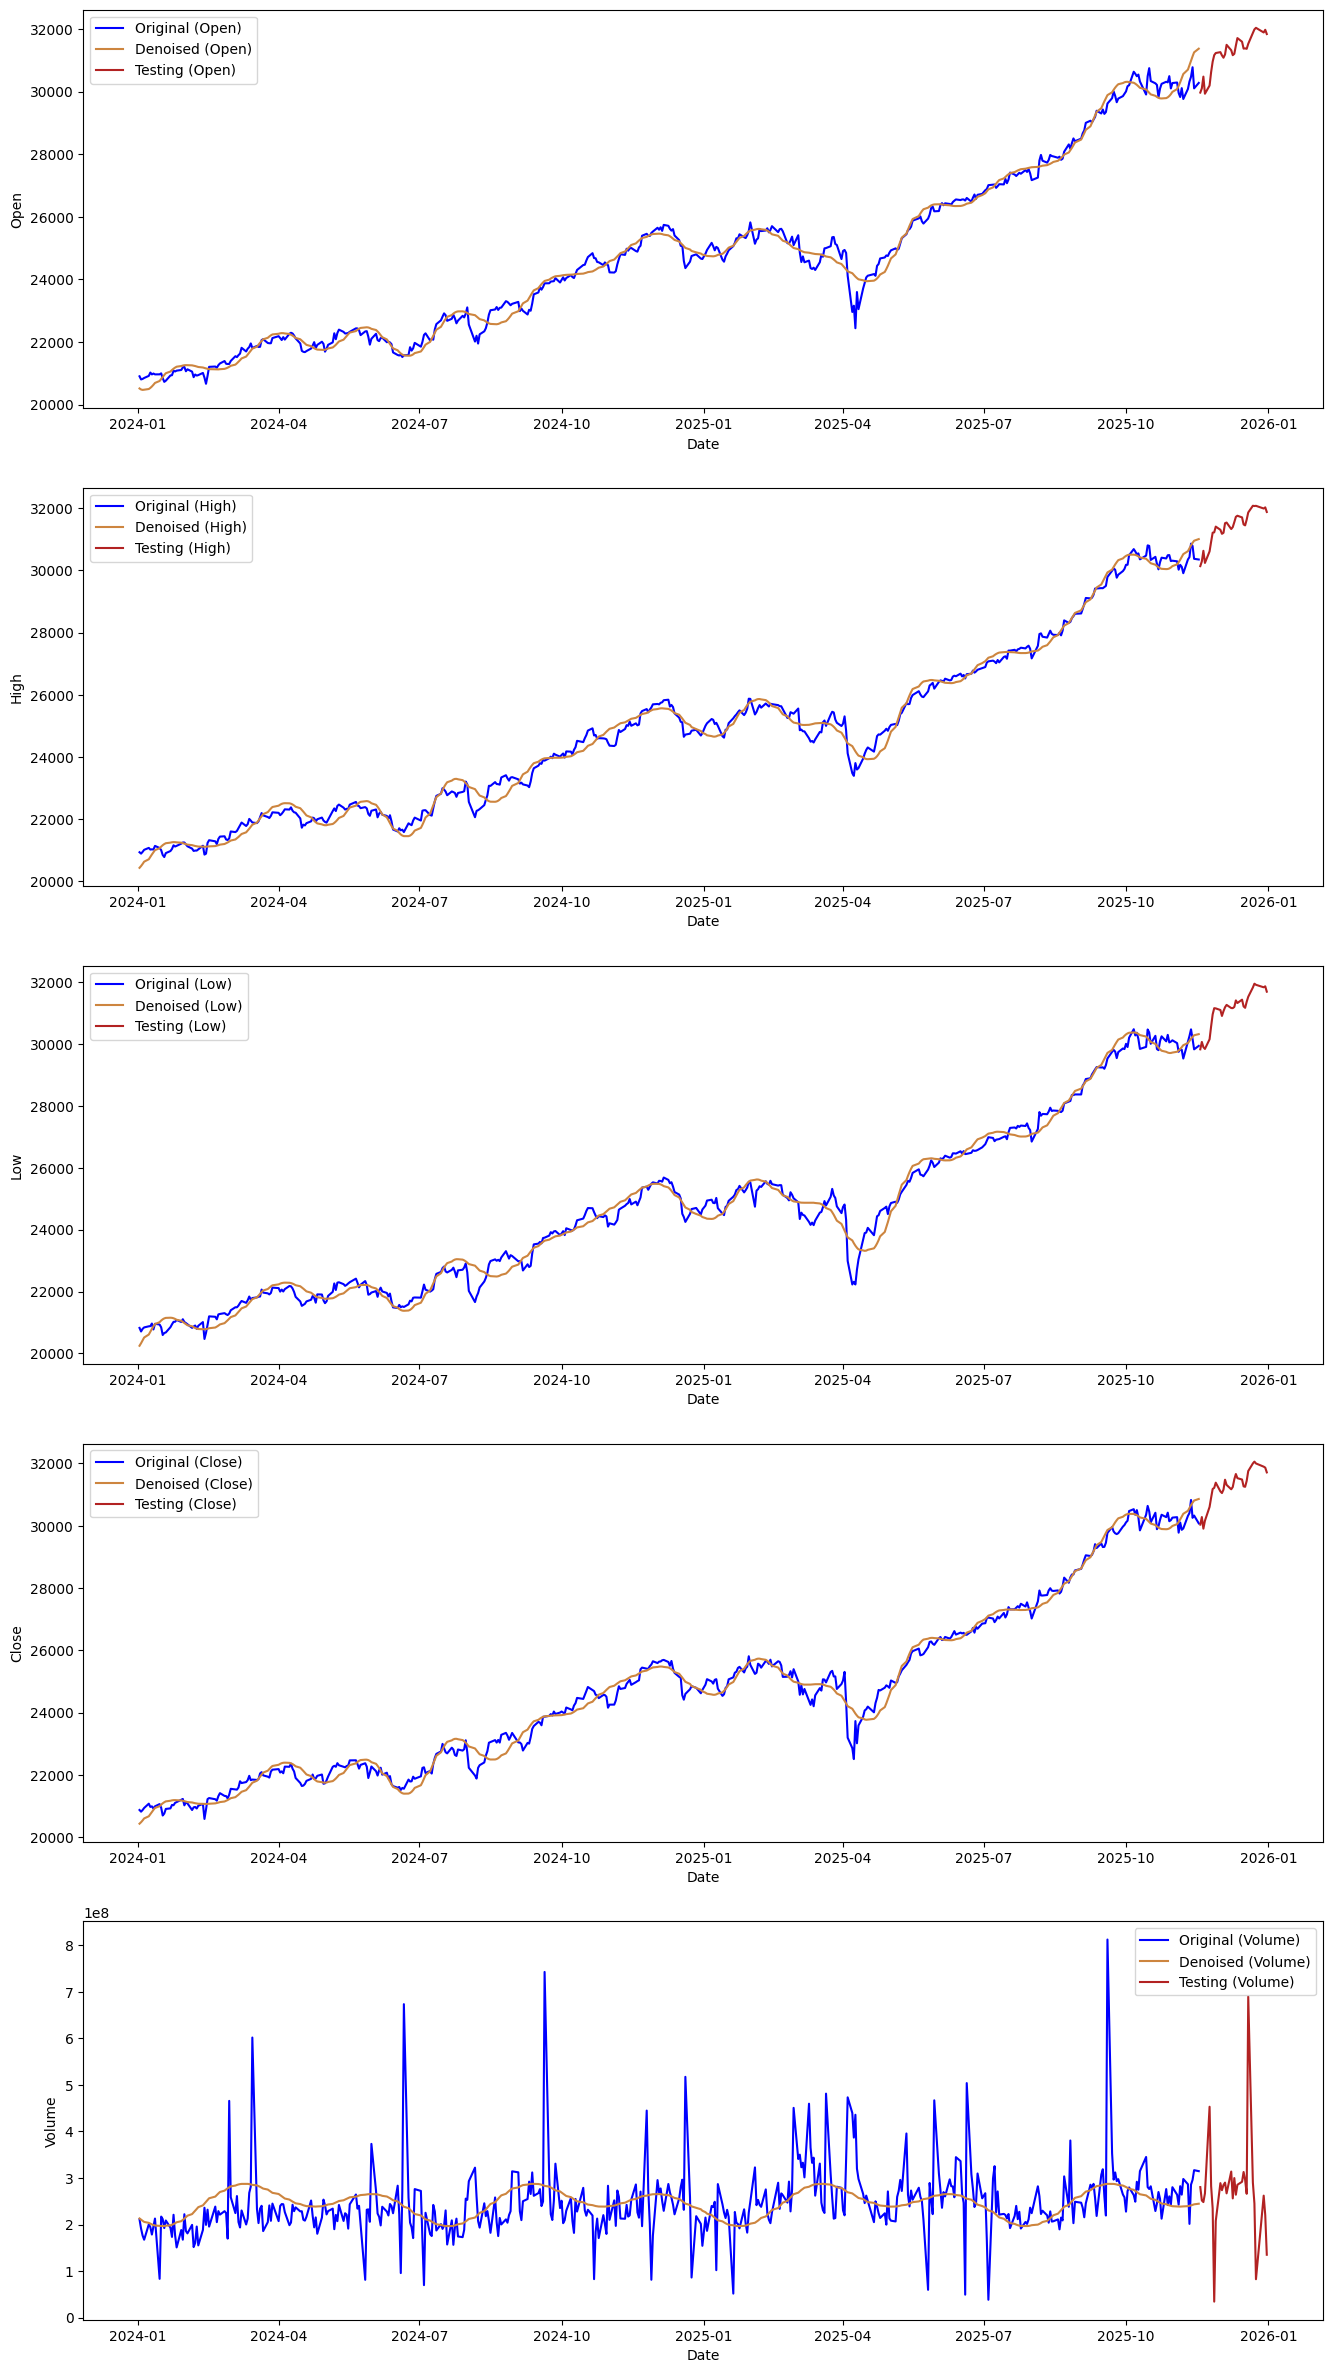

In [28]:
denoising_method = 'Padding'
quantile_percent = 0.95

test_len = 30
memory = 20


plot_yes_no = 'Yes'
plot_y_train = 'No'



method_used = '' if denoising_method=='None' else denoising_method

if os.path.exists(f'Short_LSTM_{method_used}_NRMSE.csv') and os.path.exists(f'Long_LSTM_{method_used}_NRMSE.csv'):
  print(f'Dataset found ({denoising_method})')
  print('')
  NRMSE_short_results = pd.read_csv(f'Short_LSTM_{method_used}_NRMSE.csv')
  NRMSE_long_results = pd.read_csv(f'Long_LSTM_{method_used}_NRMSE.csv')
  NRMSE_short_results = NRMSE_short_results.iloc[:,1:].values.tolist()
  NRMSE_long_results = NRMSE_long_results.iloc[:,1:].values.tolist()
else:
  NRMSE_short_results = []
  NRMSE_long_results = []

for stock_symbol in stock_symbol_list:
  stock_symbol_processed = stock_symbol.replace('.', '_')
  for i in range(len(start_date_list)):
    start_date = start_date_list[i]
    end_date = end_date_list[i]
    print(f'{stock_symbol} ({start_date} to {end_date})')
    hist, x_train, y_train, x_test, y_test, scaler = stock_processor(stock_symbol, start_date, end_date, cols_list, denoising_method, quantile_percent, plot_yes_no)

## Fourier Window Renoising:

^GSPTSE (2024-01-01 to 2026-01-01)


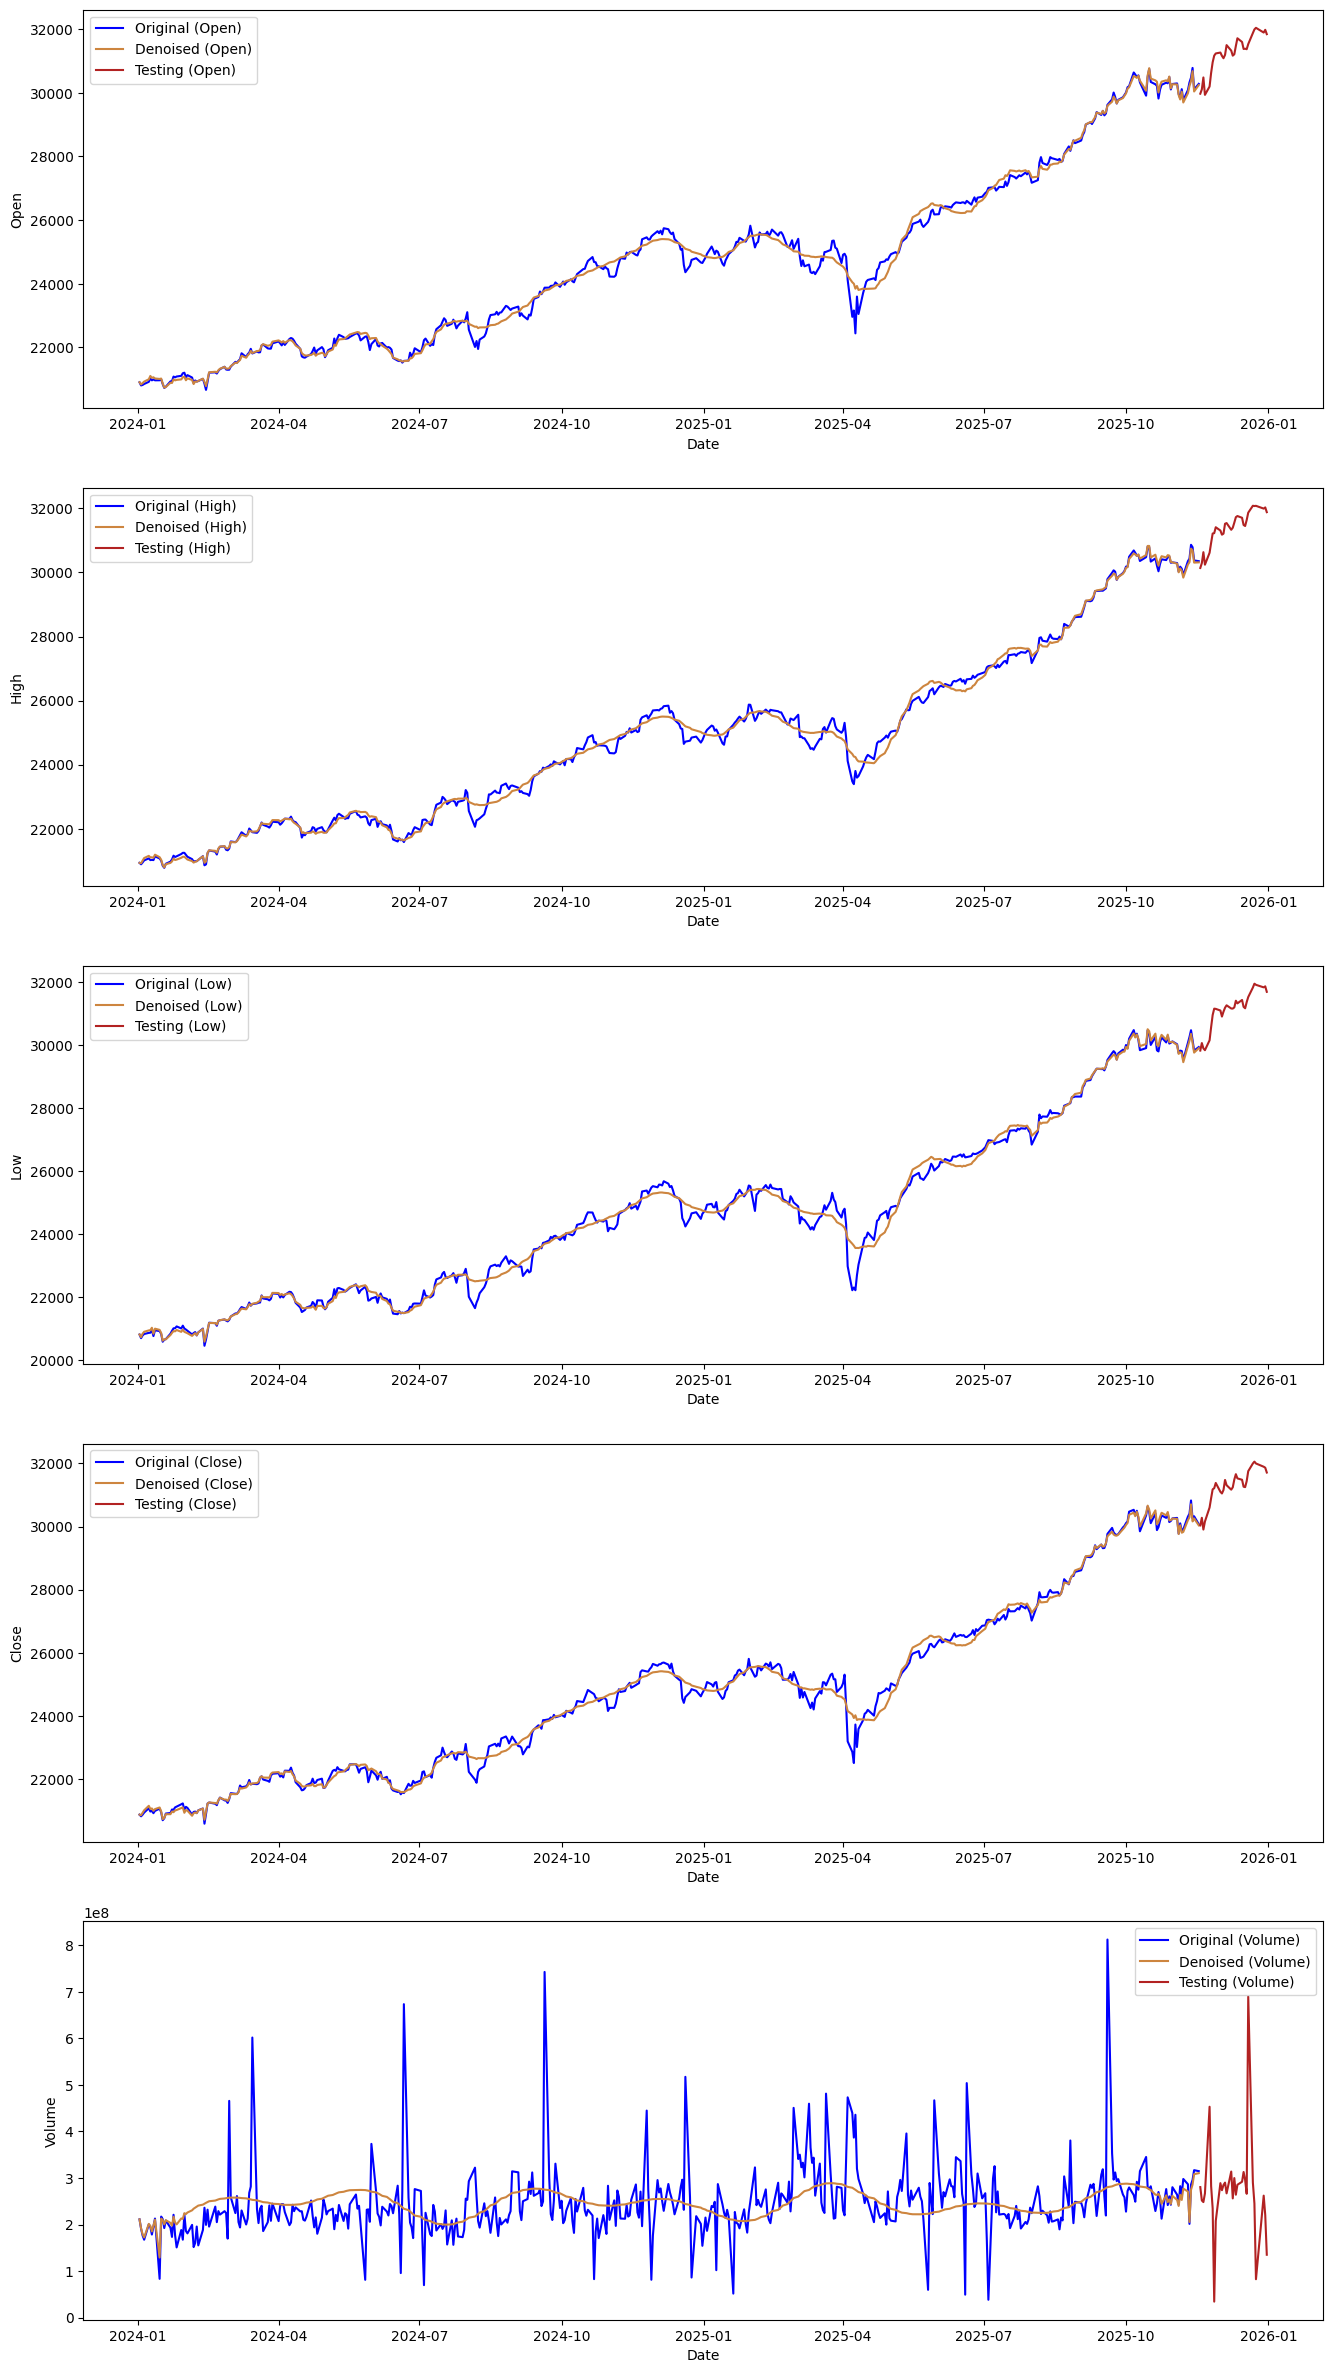

In [29]:
denoising_method = 'FWR'
quantile_percent = 0.95

test_len = 30
memory = 20


plot_yes_no = 'Yes'
plot_y_train = 'No'



method_used = '' if denoising_method=='None' else denoising_method

if os.path.exists(f'Short_LSTM_{method_used}_NRMSE.csv') and os.path.exists(f'Long_LSTM_{method_used}_NRMSE.csv'):
  print(f'Dataset found ({denoising_method})')
  print('')
  NRMSE_short_results = pd.read_csv(f'Short_LSTM_{method_used}_NRMSE.csv')
  NRMSE_long_results = pd.read_csv(f'Long_LSTM_{method_used}_NRMSE.csv')
  NRMSE_short_results = NRMSE_short_results.iloc[:,1:].values.tolist()
  NRMSE_long_results = NRMSE_long_results.iloc[:,1:].values.tolist()
else:
  NRMSE_short_results = []
  NRMSE_long_results = []

for stock_symbol in stock_symbol_list:
  stock_symbol_processed = stock_symbol.replace('.', '_')
  for i in range(len(start_date_list)):
    start_date = start_date_list[i]
    end_date = end_date_list[i]
    print(f'{stock_symbol} ({start_date} to {end_date})')
    hist, x_train, y_train, x_test, y_test, scaler = stock_processor(stock_symbol, start_date, end_date, cols_list, denoising_method, quantile_percent, plot_yes_no)

## Fourier Linear Drift Denoising:

^GSPTSE (2024-01-01 to 2026-01-01)


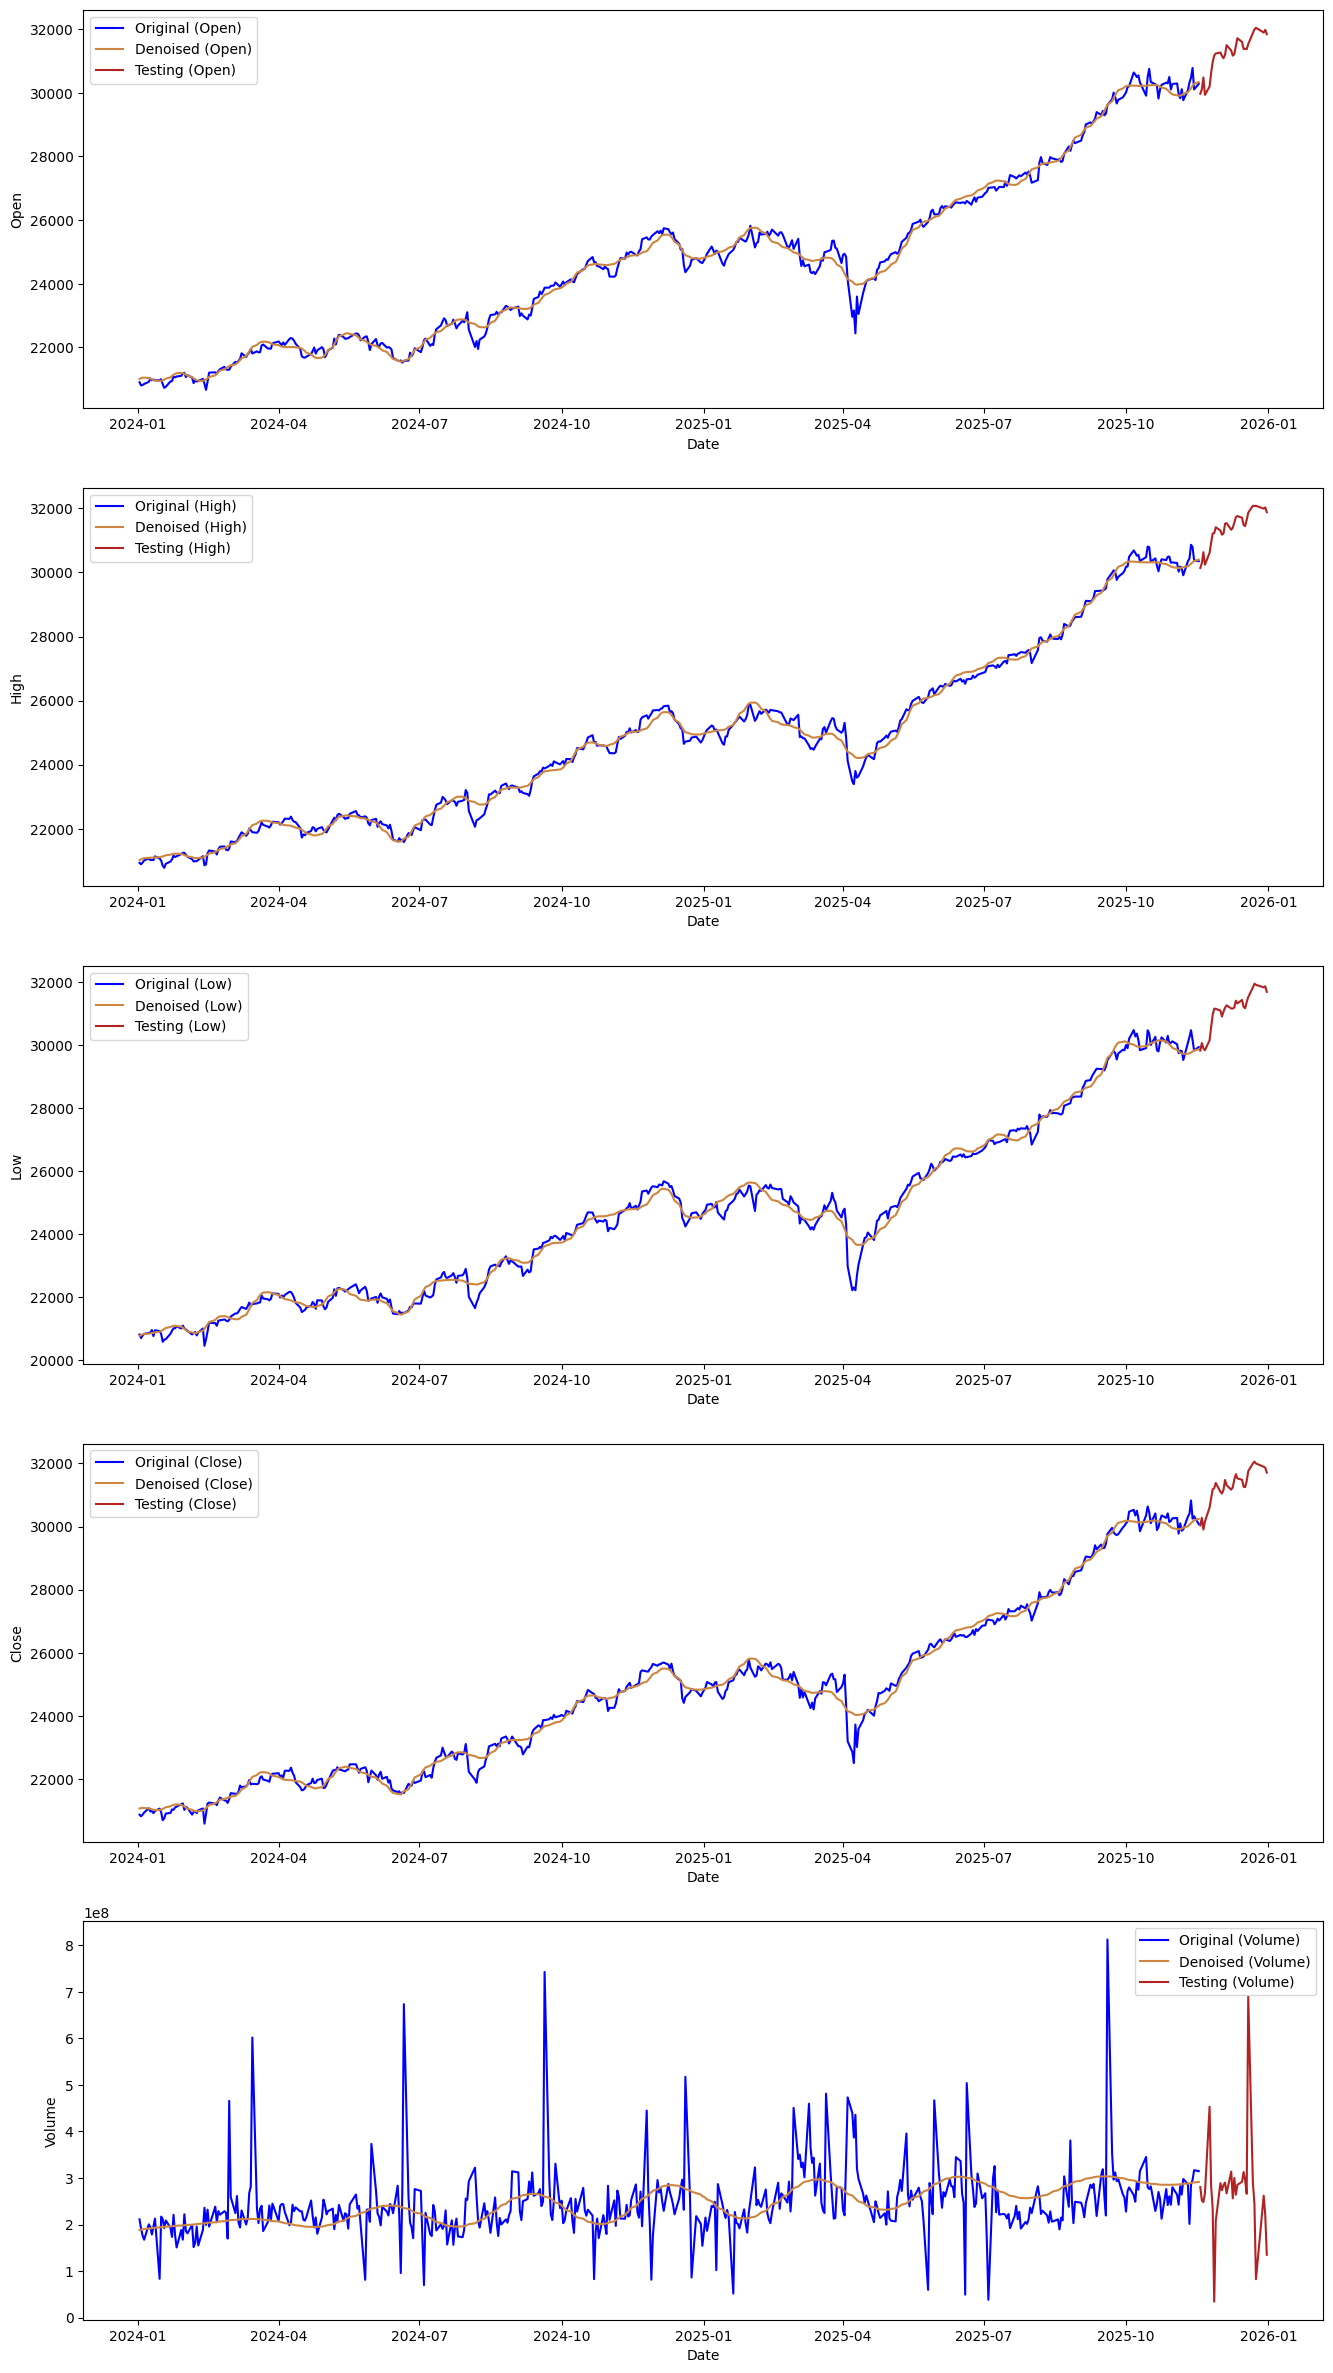

In [30]:
denoising_method = 'LinDrift'
quantile_percent = 0.95

test_len = 30
memory = 20


plot_yes_no = 'Yes'
plot_y_train = 'No'



method_used = '' if denoising_method=='None' else denoising_method

if os.path.exists(f'Short_LSTM_{method_used}_NRMSE.csv') and os.path.exists(f'Long_LSTM_{method_used}_NRMSE.csv'):
  print(f'Dataset found ({denoising_method})')
  print('')
  NRMSE_short_results = pd.read_csv(f'Short_LSTM_{method_used}_NRMSE.csv')
  NRMSE_long_results = pd.read_csv(f'Long_LSTM_{method_used}_NRMSE.csv')
  NRMSE_short_results = NRMSE_short_results.iloc[:,1:].values.tolist()
  NRMSE_long_results = NRMSE_long_results.iloc[:,1:].values.tolist()
else:
  NRMSE_short_results = []
  NRMSE_long_results = []

for stock_symbol in stock_symbol_list:
  stock_symbol_processed = stock_symbol.replace('.', '_')
  for i in range(len(start_date_list)):
    start_date = start_date_list[i]
    end_date = end_date_list[i]
    print(f'{stock_symbol} ({start_date} to {end_date})')
    hist, x_train, y_train, x_test, y_test, scaler = stock_processor(stock_symbol, start_date, end_date, cols_list, denoising_method, quantile_percent, plot_yes_no)

## Stationary Signal Denoising:

^GSPTSE (2024-01-01 to 2026-01-01)


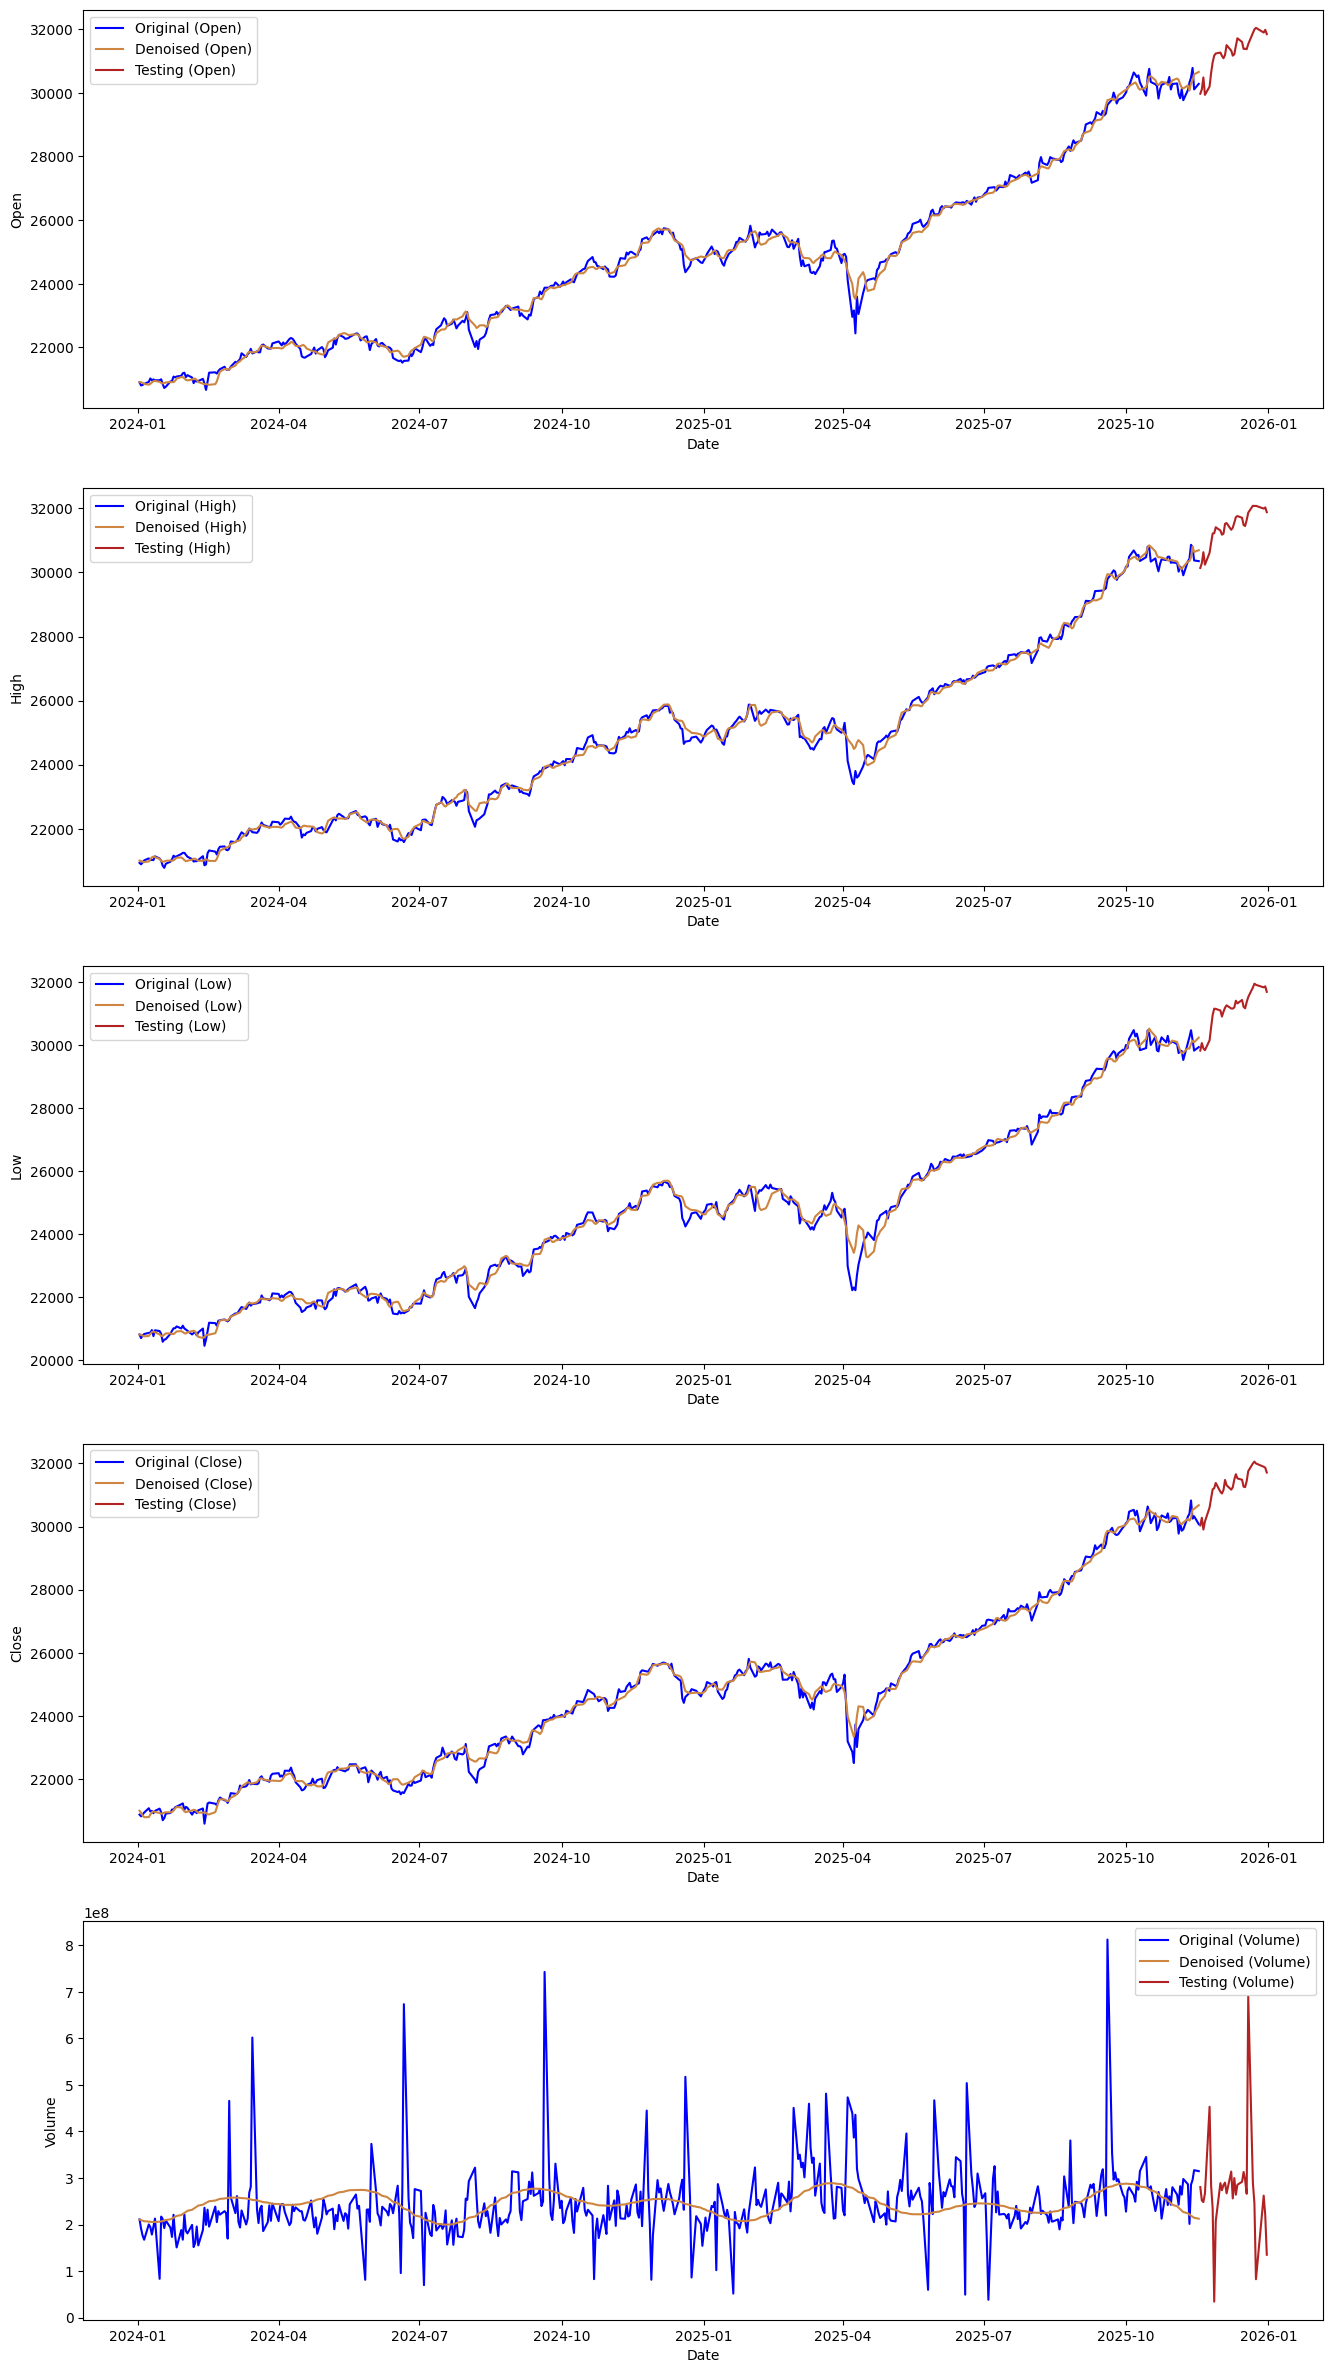

In [31]:
denoising_method = 'Stationary'
quantile_percent = 0.95

test_len = 30
memory = 20


plot_yes_no = 'Yes'
plot_y_train = 'No'



method_used = '' if denoising_method=='None' else denoising_method

if os.path.exists(f'Short_LSTM_{method_used}_NRMSE.csv') and os.path.exists(f'Long_LSTM_{method_used}_NRMSE.csv'):
  print(f'Dataset found ({denoising_method})')
  print('')
  NRMSE_short_results = pd.read_csv(f'Short_LSTM_{method_used}_NRMSE.csv')
  NRMSE_long_results = pd.read_csv(f'Long_LSTM_{method_used}_NRMSE.csv')
  NRMSE_short_results = NRMSE_short_results.iloc[:,1:].values.tolist()
  NRMSE_long_results = NRMSE_long_results.iloc[:,1:].values.tolist()
else:
  NRMSE_short_results = []
  NRMSE_long_results = []

for stock_symbol in stock_symbol_list:
  stock_symbol_processed = stock_symbol.replace('.', '_')
  for i in range(len(start_date_list)):
    start_date = start_date_list[i]
    end_date = end_date_list[i]
    print(f'{stock_symbol} ({start_date} to {end_date})')
    hist, x_train, y_train, x_test, y_test, scaler = stock_processor(stock_symbol, start_date, end_date, cols_list, denoising_method, quantile_percent, plot_yes_no)

## Fejer Summation Denoising:


^GSPTSE (2024-01-01 to 2026-01-01)


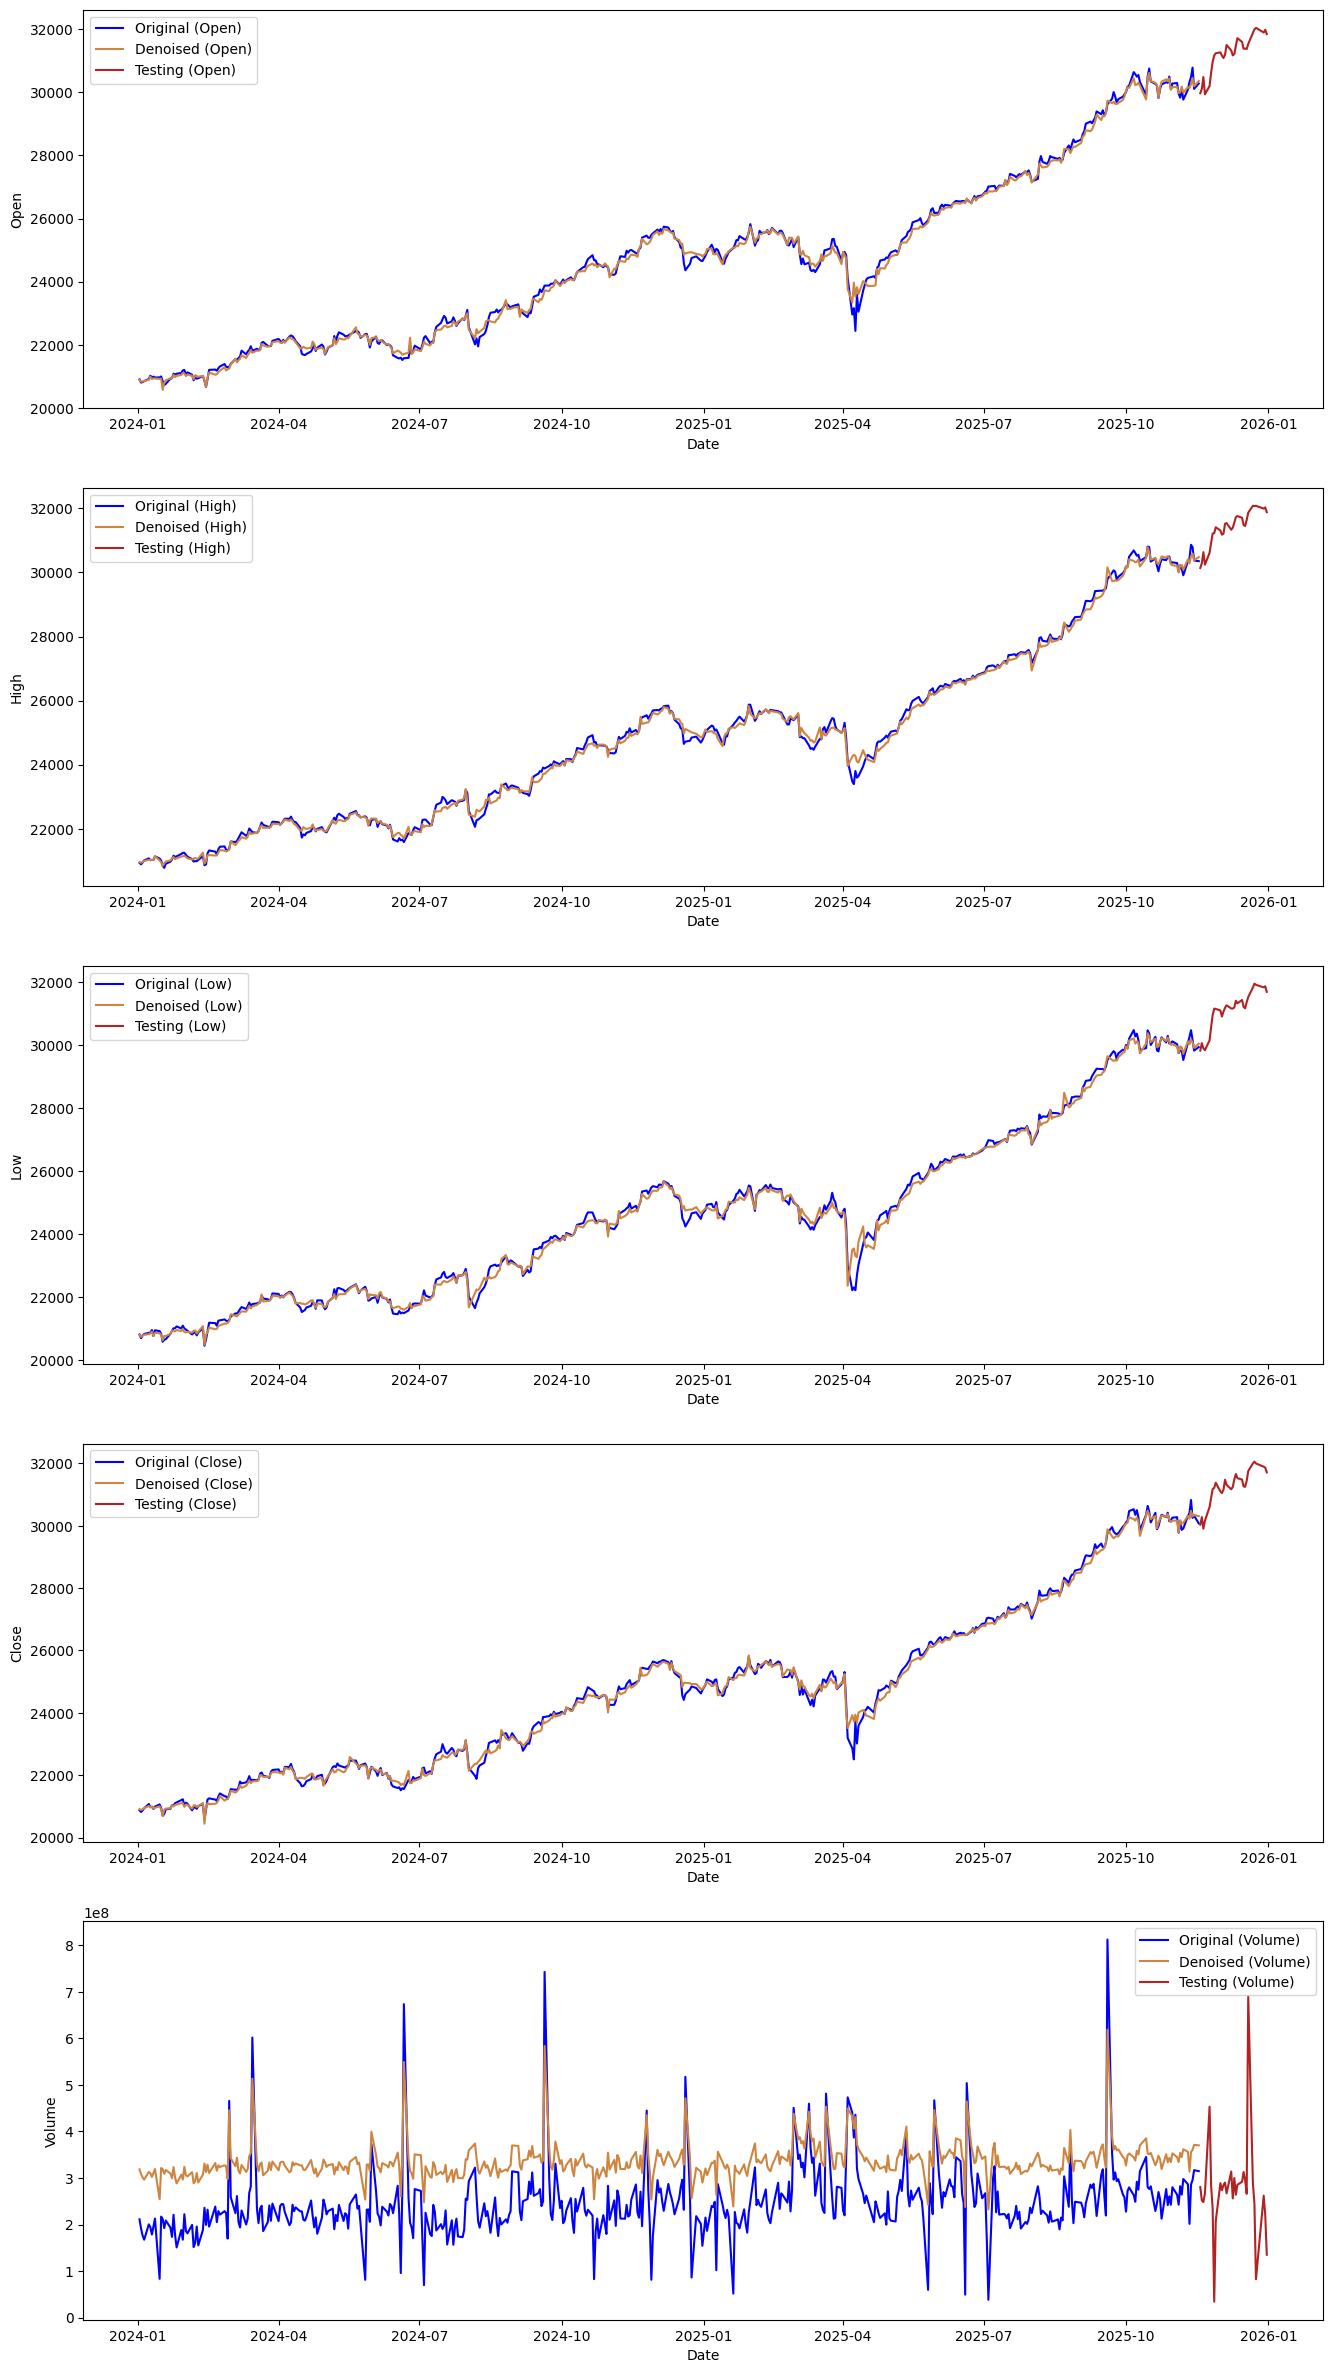

In [32]:
denoising_method = 'Fejer'
quantile_percent = 0.95

test_len = 30
memory = 20


plot_yes_no = 'Yes'
plot_y_train = 'No'



method_used = '' if denoising_method=='None' else denoising_method

if os.path.exists(f'Short_LSTM_{method_used}_NRMSE.csv') and os.path.exists(f'Long_LSTM_{method_used}_NRMSE.csv'):
  print(f'Dataset found ({denoising_method})')
  print('')
  NRMSE_short_results = pd.read_csv(f'Short_LSTM_{method_used}_NRMSE.csv')
  NRMSE_long_results = pd.read_csv(f'Long_LSTM_{method_used}_NRMSE.csv')
  NRMSE_short_results = NRMSE_short_results.iloc[:,1:].values.tolist()
  NRMSE_long_results = NRMSE_long_results.iloc[:,1:].values.tolist()
else:
  NRMSE_short_results = []
  NRMSE_long_results = []

for stock_symbol in stock_symbol_list:
  stock_symbol_processed = stock_symbol.replace('.', '_')
  for i in range(len(start_date_list)):
    start_date = start_date_list[i]
    end_date = end_date_list[i]
    print(f'{stock_symbol} ({start_date} to {end_date})')
    hist, x_train, y_train, x_test, y_test, scaler = stock_processor(stock_symbol, start_date, end_date, cols_list, denoising_method, quantile_percent, plot_yes_no)

## Lanczos $\sigma$-Approximation:


^GSPTSE (2024-01-01 to 2026-01-01)


/tmp/ipykernel_14147/1807061038.py:67: RuntimeWarning: invalid value encountered in divide
  sinc_factor = np.sin(np.pi*np.arange(len(fxt))/len(fxt))/(np.pi*np.arange(len(fxt))/len(fxt))
/tmp/ipykernel_14147/1807061038.py:67: RuntimeWarning: invalid value encountered in divide
  sinc_factor = np.sin(np.pi*np.arange(len(fxt))/len(fxt))/(np.pi*np.arange(len(fxt))/len(fxt))
/tmp/ipykernel_14147/1807061038.py:67: RuntimeWarning: invalid value encountered in divide
  sinc_factor = np.sin(np.pi*np.arange(len(fxt))/len(fxt))/(np.pi*np.arange(len(fxt))/len(fxt))
/tmp/ipykernel_14147/1807061038.py:67: RuntimeWarning: invalid value encountered in divide
  sinc_factor = np.sin(np.pi*np.arange(len(fxt))/len(fxt))/(np.pi*np.arange(len(fxt))/len(fxt))
/tmp/ipykernel_14147/1807061038.py:67: RuntimeWarning: invalid value encountered in divide
  sinc_factor = np.sin(np.pi*np.arange(len(fxt))/len(fxt))/(np.pi*np.arange(len(fxt))/len(fxt))


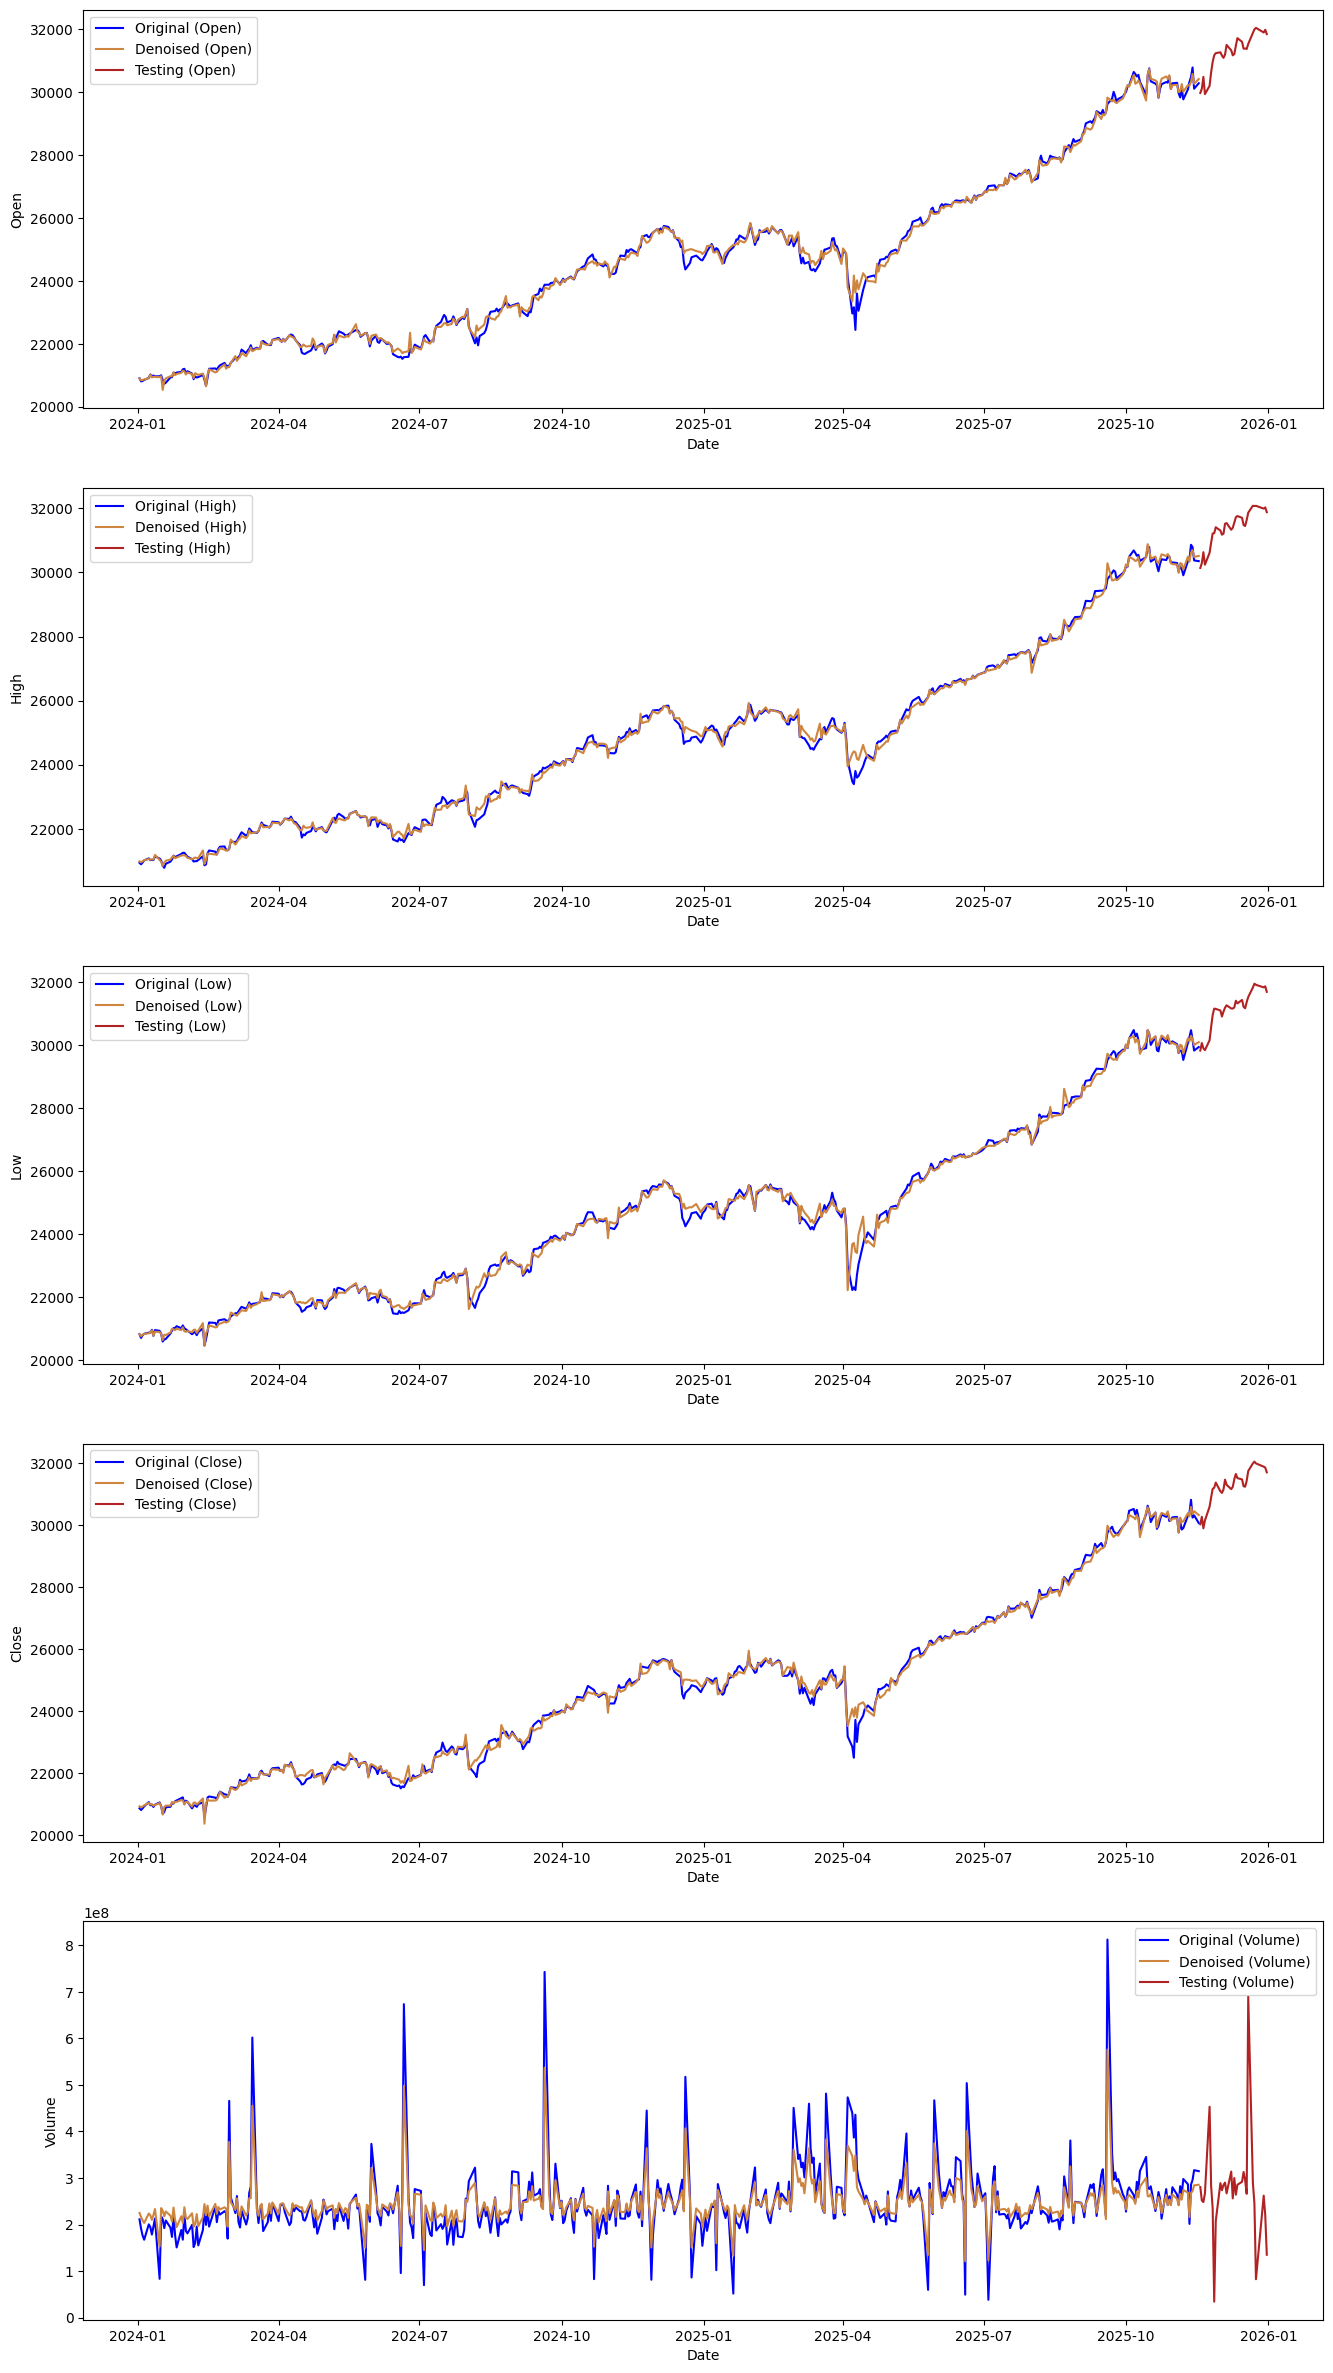

In [33]:
denoising_method = 'Lanczos'
quantile_percent = 0.95

test_len = 30
memory = 20


plot_yes_no = 'Yes'
plot_y_train = 'No'



method_used = '' if denoising_method=='None' else denoising_method

if os.path.exists(f'Short_LSTM_{method_used}_NRMSE.csv') and os.path.exists(f'Long_LSTM_{method_used}_NRMSE.csv'):
  print(f'Dataset found ({denoising_method})')
  print('')
  NRMSE_short_results = pd.read_csv(f'Short_LSTM_{method_used}_NRMSE.csv')
  NRMSE_long_results = pd.read_csv(f'Long_LSTM_{method_used}_NRMSE.csv')
  NRMSE_short_results = NRMSE_short_results.iloc[:,1:].values.tolist()
  NRMSE_long_results = NRMSE_long_results.iloc[:,1:].values.tolist()
else:
  NRMSE_short_results = []
  NRMSE_long_results = []

for stock_symbol in stock_symbol_list:
  stock_symbol_processed = stock_symbol.replace('.', '_')
  for i in range(len(start_date_list)):
    start_date = start_date_list[i]
    end_date = end_date_list[i]
    print(f'{stock_symbol} ({start_date} to {end_date})')
    hist, x_train, y_train, x_test, y_test, scaler = stock_processor(stock_symbol, start_date, end_date, cols_list, denoising_method, quantile_percent, plot_yes_no)

## Stationary Exponential Denoising:

^GSPTSE (2024-01-01 to 2026-01-01)


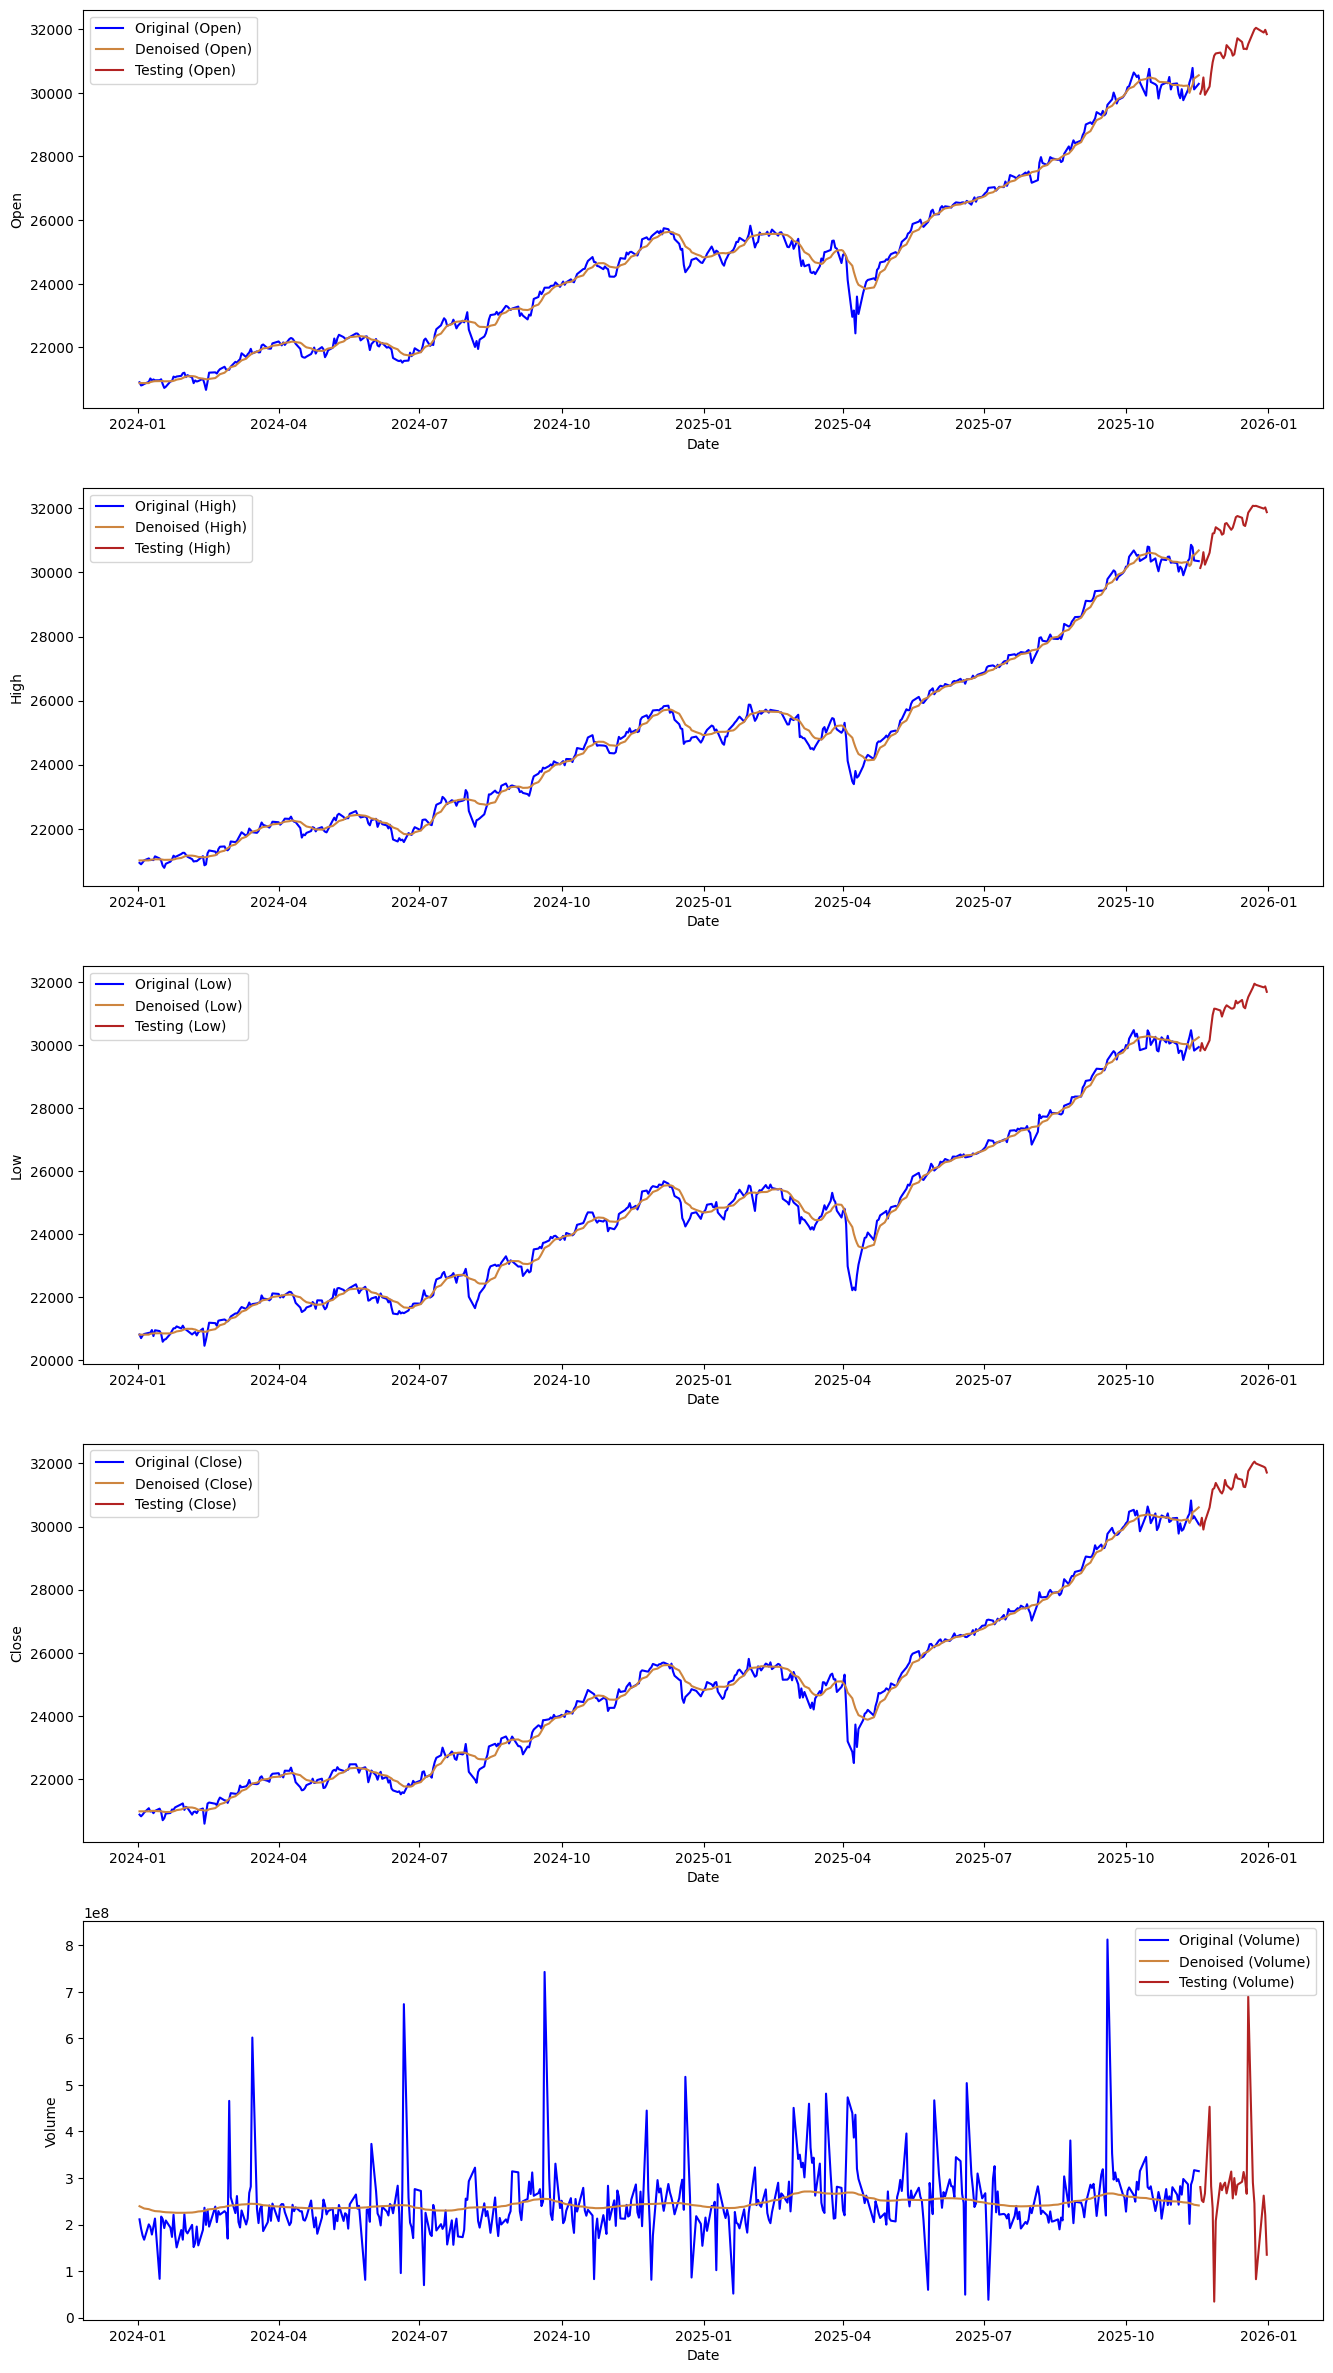

In [34]:
denoising_method = 'Exponential'
quantile_percent = 0.95

test_len = 30
memory = 20


plot_yes_no = 'Yes'
plot_y_train = 'No'



method_used = '' if denoising_method=='None' else denoising_method

if os.path.exists(f'Short_LSTM_{method_used}_NRMSE.csv') and os.path.exists(f'Long_LSTM_{method_used}_NRMSE.csv'):
  print(f'Dataset found ({denoising_method})')
  print('')
  NRMSE_short_results = pd.read_csv(f'Short_LSTM_{method_used}_NRMSE.csv')
  NRMSE_long_results = pd.read_csv(f'Long_LSTM_{method_used}_NRMSE.csv')
  NRMSE_short_results = NRMSE_short_results.iloc[:,1:].values.tolist()
  NRMSE_long_results = NRMSE_long_results.iloc[:,1:].values.tolist()
else:
  NRMSE_short_results = []
  NRMSE_long_results = []

for stock_symbol in stock_symbol_list:
  stock_symbol_processed = stock_symbol.replace('.', '_')
  for i in range(len(start_date_list)):
    start_date = start_date_list[i]
    end_date = end_date_list[i]
    print(f'{stock_symbol} ({start_date} to {end_date})')
    hist, x_train, y_train, x_test, y_test, scaler = stock_processor(stock_symbol, start_date, end_date, cols_list, denoising_method, quantile_percent, plot_yes_no)